In [2]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
from sklearn.datasets import make_classification

In [4]:
# create the dataset
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)

In [5]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,0.964799,-0.066449,0.986768,-0.358079,0.997266,1.181890,-1.615679,-1.210161,-0.628077,1.227274
1,-0.916511,-0.566395,-1.008614,0.831617,-1.176962,1.820544,1.752375,-0.984534,0.363896,0.209470
2,-0.109484,-0.432774,-0.457649,0.793818,-0.268646,-1.836360,1.239086,-0.246383,-1.058145,-0.297376
3,1.750412,2.023606,1.688159,0.006800,-1.607661,0.184741,-2.619427,-0.357445,-1.473127,-0.190039
4,-0.224726,-0.711303,-0.220778,0.117124,1.536061,0.597538,0.348645,-0.939156,0.175915,0.236224
...,...,...,...,...,...,...,...,...,...,...
995,-1.367638,1.462255,-1.154918,-0.290454,-0.413424,0.032396,1.545490,1.428760,1.687092,1.072542
996,-1.514876,-3.221016,-1.300744,0.395599,-0.527994,1.353069,1.777506,-1.680870,1.798510,0.034272
997,1.674633,1.754933,1.586154,0.018402,-1.514470,0.321593,-2.417694,0.692723,-1.503850,0.225264
998,-0.778609,-0.835689,-0.194842,1.097220,0.180071,-0.272933,-0.533188,-0.497354,2.472138,0.867187


In [6]:
# Train Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [7]:
# Scaling the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)


In [8]:
# Model training
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression()

In [9]:
logistic.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
y_pred=logistic.predict(X_test)
y_pred

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0])

In [11]:
# performance metrices
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [12]:
score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.84
[[ 98  15]
 [ 25 112]]
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       113
           1       0.88      0.82      0.85       137

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250



Text(0.5, 1.0, 'Training Data')

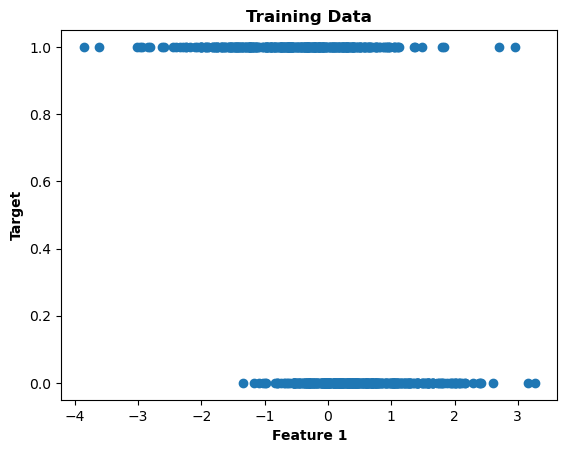

In [13]:
plt.scatter(X_train[:, 0], y_train)
plt.xlabel('Feature 1',weight='bold')
plt.ylabel('Target',weight='bold')
plt.title('Training Data', weight='bold')

## Hyperparameter Tuning and Cross Validation

In [14]:
model=LogisticRegression(max_iter=5000)
penalty=["l1","l2"]
c_values=[0.001,0.01,0.1,1,10,100]
solver=["liblinear","saga"]

In [15]:
params=dict(penalty=penalty,C=c_values,solver=solver)

In [16]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

## Grid Search CV

In [17]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [19]:
grid_search.fit(X_train_scaled,y_train)

,estimator,LogisticRegre...max_iter=5000)
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [20]:
grid_search.best_params_

{'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}

In [21]:
grid_search.best_score_

np.float64(0.876)

In [22]:
y_pred=grid_search.predict(X_test_scaled)

In [23]:
score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.84
[[102  11]
 [ 29 108]]
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       113
           1       0.91      0.79      0.84       137

    accuracy                           0.84       250
   macro avg       0.84      0.85      0.84       250
weighted avg       0.85      0.84      0.84       250



## Randomized Search CV

In [24]:
from sklearn.model_selection import RandomizedSearchCV
model=LogisticRegression(max_iter=5000)
randomcv=RandomizedSearchCV(estimator=model,param_distributions=params,scoring='accuracy',cv=5)

In [25]:
randomcv.fit(X_train_scaled,y_train)

,estimator,LogisticRegre...max_iter=5000)
,param_distributions,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [26]:
randomcv.best_params_


{'solver': 'liblinear', 'penalty': 'l1', 'C': 0.01}

In [27]:
randomcv.best_score_

np.float64(0.8760000000000001)

In [28]:
y_pred=randomcv.predict(X_test_scaled)  

In [29]:
y_pred

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0])

In [30]:
score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.84
[[102  11]
 [ 29 108]]
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       113
           1       0.91      0.79      0.84       137

    accuracy                           0.84       250
   macro avg       0.84      0.85      0.84       250
weighted avg       0.85      0.84      0.84       250



## Logistic Regresssion for Multiclass Classification Problem

In [31]:
## creating the dataset
X,y=make_classification(n_samples=1000,n_informative=3,n_features=10,n_classes=3,random_state=42)

In [32]:
y

array([1, 2, 1, 1, 2, 1, 1, 0, 2, 2, 2, 0, 1, 0, 2, 1, 2, 1, 0, 1, 1, 1,
       2, 2, 1, 2, 2, 0, 1, 2, 0, 1, 0, 2, 0, 1, 0, 0, 2, 0, 1, 0, 2, 1,
       2, 0, 2, 0, 2, 0, 0, 0, 2, 1, 1, 1, 1, 2, 0, 0, 2, 1, 0, 0, 1, 2,
       0, 2, 2, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0,
       0, 1, 1, 2, 1, 0, 1, 2, 0, 2, 0, 0, 2, 1, 0, 2, 0, 2, 2, 0, 2, 0,
       0, 0, 0, 2, 1, 2, 1, 0, 2, 0, 0, 2, 1, 0, 2, 1, 0, 0, 2, 2, 0, 0,
       0, 2, 1, 2, 2, 0, 2, 0, 1, 2, 1, 2, 1, 1, 2, 0, 0, 1, 0, 2, 0, 0,
       0, 1, 1, 2, 1, 2, 2, 0, 0, 0, 1, 1, 0, 2, 1, 2, 2, 2, 1, 1, 0, 2,
       1, 0, 2, 1, 2, 1, 2, 0, 1, 1, 0, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2,
       1, 2, 1, 1, 0, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 0, 2, 2, 2, 0,
       2, 0, 1, 1, 2, 1, 2, 2, 2, 2, 0, 1, 0, 0, 0, 0, 2, 2, 2, 1, 1, 1,
       0, 2, 0, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 2, 1, 0, 1, 1, 1, 2, 2, 2,
       2, 2, 2, 0, 0, 0, 2, 1, 1, 1, 1, 2, 1, 2, 2, 1, 2, 1, 0, 0, 2, 2,
       2, 1, 1, 1, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 1,

In [33]:
# Train Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [34]:
logistic=LogisticRegression(multi_class='ovr',max_iter=5000)
logistic.fit(X_train,y_train)
y_pred=logistic.predict(X_test)


c:\Users\karra\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [35]:
y_pred

array([2, 0, 1, 2, 0, 1, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0,
       2, 0, 1, 0, 2, 1, 0, 2, 2, 0, 1, 0, 0, 2, 2, 2, 1, 0, 0, 1, 2, 0,
       1, 2, 1, 0, 1, 1, 2, 0, 1, 0, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 1, 1,
       0, 1, 0, 1, 0, 2, 2, 0, 0, 0, 2, 1, 1, 2, 2, 0, 2, 1, 0, 1, 1, 2,
       1, 1, 2, 2, 1, 2, 2, 2, 1, 0, 0, 0, 0, 2, 1, 0, 2, 1, 1, 0, 0, 2,
       0, 1, 2, 0, 0, 0, 1, 1, 2, 2, 1, 0, 0, 1, 2, 0, 0, 1, 0, 2, 1, 0,
       2, 2, 2, 0, 0, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 0, 0, 1, 2, 0, 0, 2,
       1, 0, 0, 0, 2, 0, 0, 0, 2, 2, 2, 2, 2, 1, 2, 1, 0, 2, 1, 0, 0, 2,
       0, 1, 1, 2, 2, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 2, 1, 2, 2, 1, 2,
       0, 1, 2, 2, 1, 1, 0, 2, 1, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 2, 1, 0, 1, 2, 0, 0, 2,
       0, 2, 0, 0, 2, 2, 0, 2, 2, 0, 1, 2, 2, 0, 1, 1, 0, 1, 2, 0, 2, 2,
       0, 0, 0, 2, 1, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 0, 1, 0, 2, 2, 2,
       0, 2, 2, 0, 2, 2, 0, 2, 0, 0, 2, 2, 0, 1])

In [36]:
score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.68
[[79 16  8]
 [31 38 27]
 [ 3 11 87]]
              precision    recall  f1-score   support

           0       0.70      0.77      0.73       103
           1       0.58      0.40      0.47        96
           2       0.71      0.86      0.78       101

    accuracy                           0.68       300
   macro avg       0.67      0.67      0.66       300
weighted avg       0.67      0.68      0.66       300



## Hyper parameter Tuning and Cross Validation

In [37]:
model=LogisticRegression(max_iter=5000)
penalty=["l1","l2"]
c_values=[0.001,0.01,0.1,1,10,100]
solver=["liblinear","saga"]

In [38]:
params=dict(penalty=penalty,C=c_values,solver=solver)

In [39]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

## Logistic Regression for Imbalanced Dataset

In [40]:
# creating a synthetic classification imbalanced dataset
from collections import Counter
from sklearn.datasets import make_classification

In [41]:
X,y=make_classification(n_samples=10000,n_features=10,n_clusters_per_class=1,n_classes=2,weights=[0.99],random_state=10)

In [42]:
X

array([[ 1.06518486,  0.61424205, -0.25801017, ...,  0.44274723,
        -1.37275537,  0.24150141],
       [ 0.84520665,  1.58981189, -1.03735321, ...,  0.43314495,
        -2.65542668, -0.59387395],
       [ 1.49940366,  1.02022199, -0.48069694, ..., -0.35537372,
        -2.15338988, -1.5949411 ],
       ...,
       [ 0.74772756,  0.99681711, -0.60832505, ..., -0.76706428,
        -1.76721302,  0.70470687],
       [ 0.69194849,  0.34471016, -0.12659024, ...,  1.28180985,
        -0.8145999 , -0.5540849 ],
       [ 0.43202883, -0.15181083,  0.198173  , ..., -0.09088515,
         0.01282606,  1.32256226]], shape=(10000, 10))

In [43]:
Counter(y)

Counter({np.int64(0): 9856, np.int64(1): 144})

<Axes: xlabel='0', ylabel='1'>

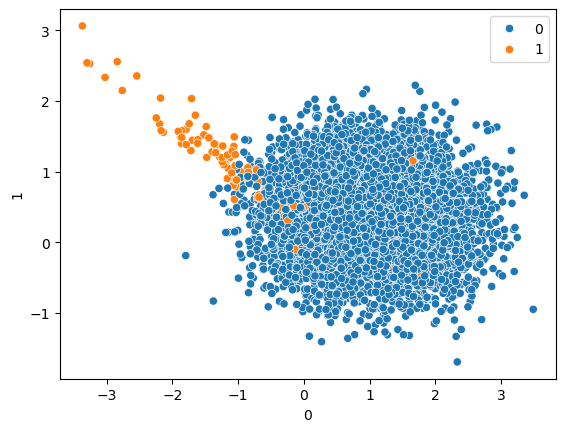

In [44]:
import seaborn as sns
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [45]:
# splitting using train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)


In [46]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [47]:
## Hyperparameter tuning
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
penalty=["l1","l2"]
c_values=[0.001,0.01,0.1,1,10,100]
solver=["saga"]
class_weight=["balanced",None]

In [48]:
params= dict(penalty=penalty,C=c_values,solver=solver,class_weight=class_weight)

In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)


In [50]:
grid.fit(X_train,y_train)

c:\Users\karra\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\karra\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\karra\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\karra\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\karra\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\karra\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

,estimator,LogisticRegression()
,param_grid,"{'C': [0.001, 0.01, ...], 'class_weight': ['balanced', None], 'penalty': ['l1', 'l2'], 'solver': ['saga']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [51]:
grid.best_params_

{'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}

In [52]:
y_pred=grid.predict(X_test)

In [53]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.9903333333333333
[[2960    0]
 [  29   11]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2960
           1       1.00      0.28      0.43        40

    accuracy                           0.99      3000
   macro avg       1.00      0.64      0.71      3000
weighted avg       0.99      0.99      0.99      3000



## Logistic Regression with ROC curve and ROC AUC score

In [54]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve , roc_auc_score
from matplotlib import pyplot as plt

In [55]:
# creating the dataset
X,y=make_classification(n_samples=1000,n_features=10,n_classes=2,random_state=1)

In [56]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [57]:
# Creating a dummy model with default 0 as output
dummy_model_prob=[ 0 for _ in range(len(y_test))]
dummy_model_prob

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [58]:
# Creating the basic logistic Model
model=LogisticRegression()
model.fit(X_train,y_train)
# prediction based on probability and focusing on positive outcome
model_prob=model.predict_proba(X_test)[:,1]

In [59]:
model_prob

array([1.44242460e-01, 7.55971183e-02, 8.59978003e-01, 2.06128941e-03,
       7.51192459e-01, 9.03921014e-01, 9.83554600e-01, 1.88829418e-02,
       5.70738660e-01, 3.43863631e-01, 1.54161560e-02, 3.97832609e-03,
       1.38957383e-01, 9.47771246e-01, 9.56988050e-01, 2.78761757e-01,
       8.78269440e-01, 7.31727058e-01, 9.92300519e-01, 9.73500958e-01,
       4.28171751e-02, 3.04401419e-01, 8.13019385e-01, 9.36677209e-01,
       6.10059040e-02, 9.35701165e-01, 5.83019706e-02, 2.10128466e-02,
       7.25484779e-01, 3.66466303e-01, 9.87750738e-02, 9.95300864e-01,
       8.95608182e-01, 8.86333185e-01, 3.93460702e-01, 2.76750729e-01,
       9.97163248e-01, 9.35078208e-01, 5.73273741e-01, 8.97785470e-01,
       8.61651583e-01, 7.26926935e-02, 9.14733571e-02, 2.73161899e-02,
       6.60878970e-02, 9.72937193e-01, 9.56073457e-01, 7.63232282e-02,
       8.81470691e-01, 1.06978915e-02, 1.31342382e-01, 9.93090306e-01,
       7.34895058e-02, 6.27816604e-01, 4.39881287e-01, 2.20772423e-02,
      

In [60]:
# Calculating the score
dummy_model_auc=roc_auc_score(y_test,dummy_model_prob)
model_auc=roc_auc_score(y_test,model_prob)
print("Dummy Model AUC:", dummy_model_auc)
print("Logistic Regression Model AUC:", model_auc)

Dummy Model AUC: 0.5
Logistic Regression Model AUC: 0.9261017384052858


In [61]:
# ROC CURVES can be obtained by plotting the true positive rate against the false positive rate 
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, dummy_model_prob)
fpr_model, tpr_model, thresholds= roc_curve(y_test, model_prob)

In [62]:
thresholds

array([           inf, 9.99149875e-01, 9.71934776e-01, 9.65359358e-01,
       9.03921014e-01, 9.03919142e-01, 8.77597527e-01, 8.77098323e-01,
       8.62646518e-01, 8.62590983e-01, 8.39658022e-01, 8.31109228e-01,
       8.11759518e-01, 8.11753399e-01, 8.09338809e-01, 8.02193591e-01,
       8.01462041e-01, 8.00897113e-01, 7.81532447e-01, 7.72036867e-01,
       7.23563315e-01, 7.22212635e-01, 7.21931801e-01, 7.01951893e-01,
       6.95666665e-01, 6.62538027e-01, 6.53921413e-01, 6.50222515e-01,
       5.37803887e-01, 4.97045292e-01, 4.79188115e-01, 4.78337672e-01,
       4.69028941e-01, 4.39881287e-01, 3.93460702e-01, 3.66466303e-01,
       3.58366081e-01, 3.45228532e-01, 3.44857580e-01, 3.13355524e-01,
       2.78761757e-01, 2.76750729e-01, 2.68768874e-01, 2.67140897e-01,
       2.65967531e-01, 2.55204591e-01, 2.49269149e-01, 1.64678828e-01,
       1.58338177e-01, 7.26660640e-02, 6.93795367e-02, 4.37354198e-03,
       3.97832609e-03, 5.61776544e-04])

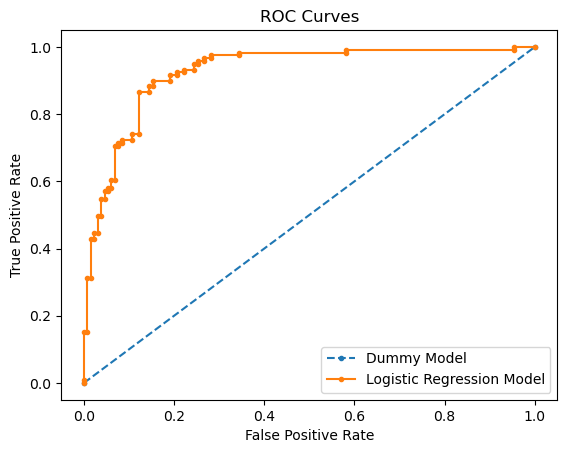

In [63]:
plt.plot(fpr_dummy, tpr_dummy, marker='.', linestyle='--', label='Dummy Model')
plt.plot(fpr_model, tpr_model, marker='.', label='Logistic Regression Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()

##### The area under the curve covered by the LOGISTIC REGRESSIO MODEL is more than that of the DUMMY MODEL.

C:\Users\karra\AppData\Local\Temp\ipykernel_20656\321147689.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


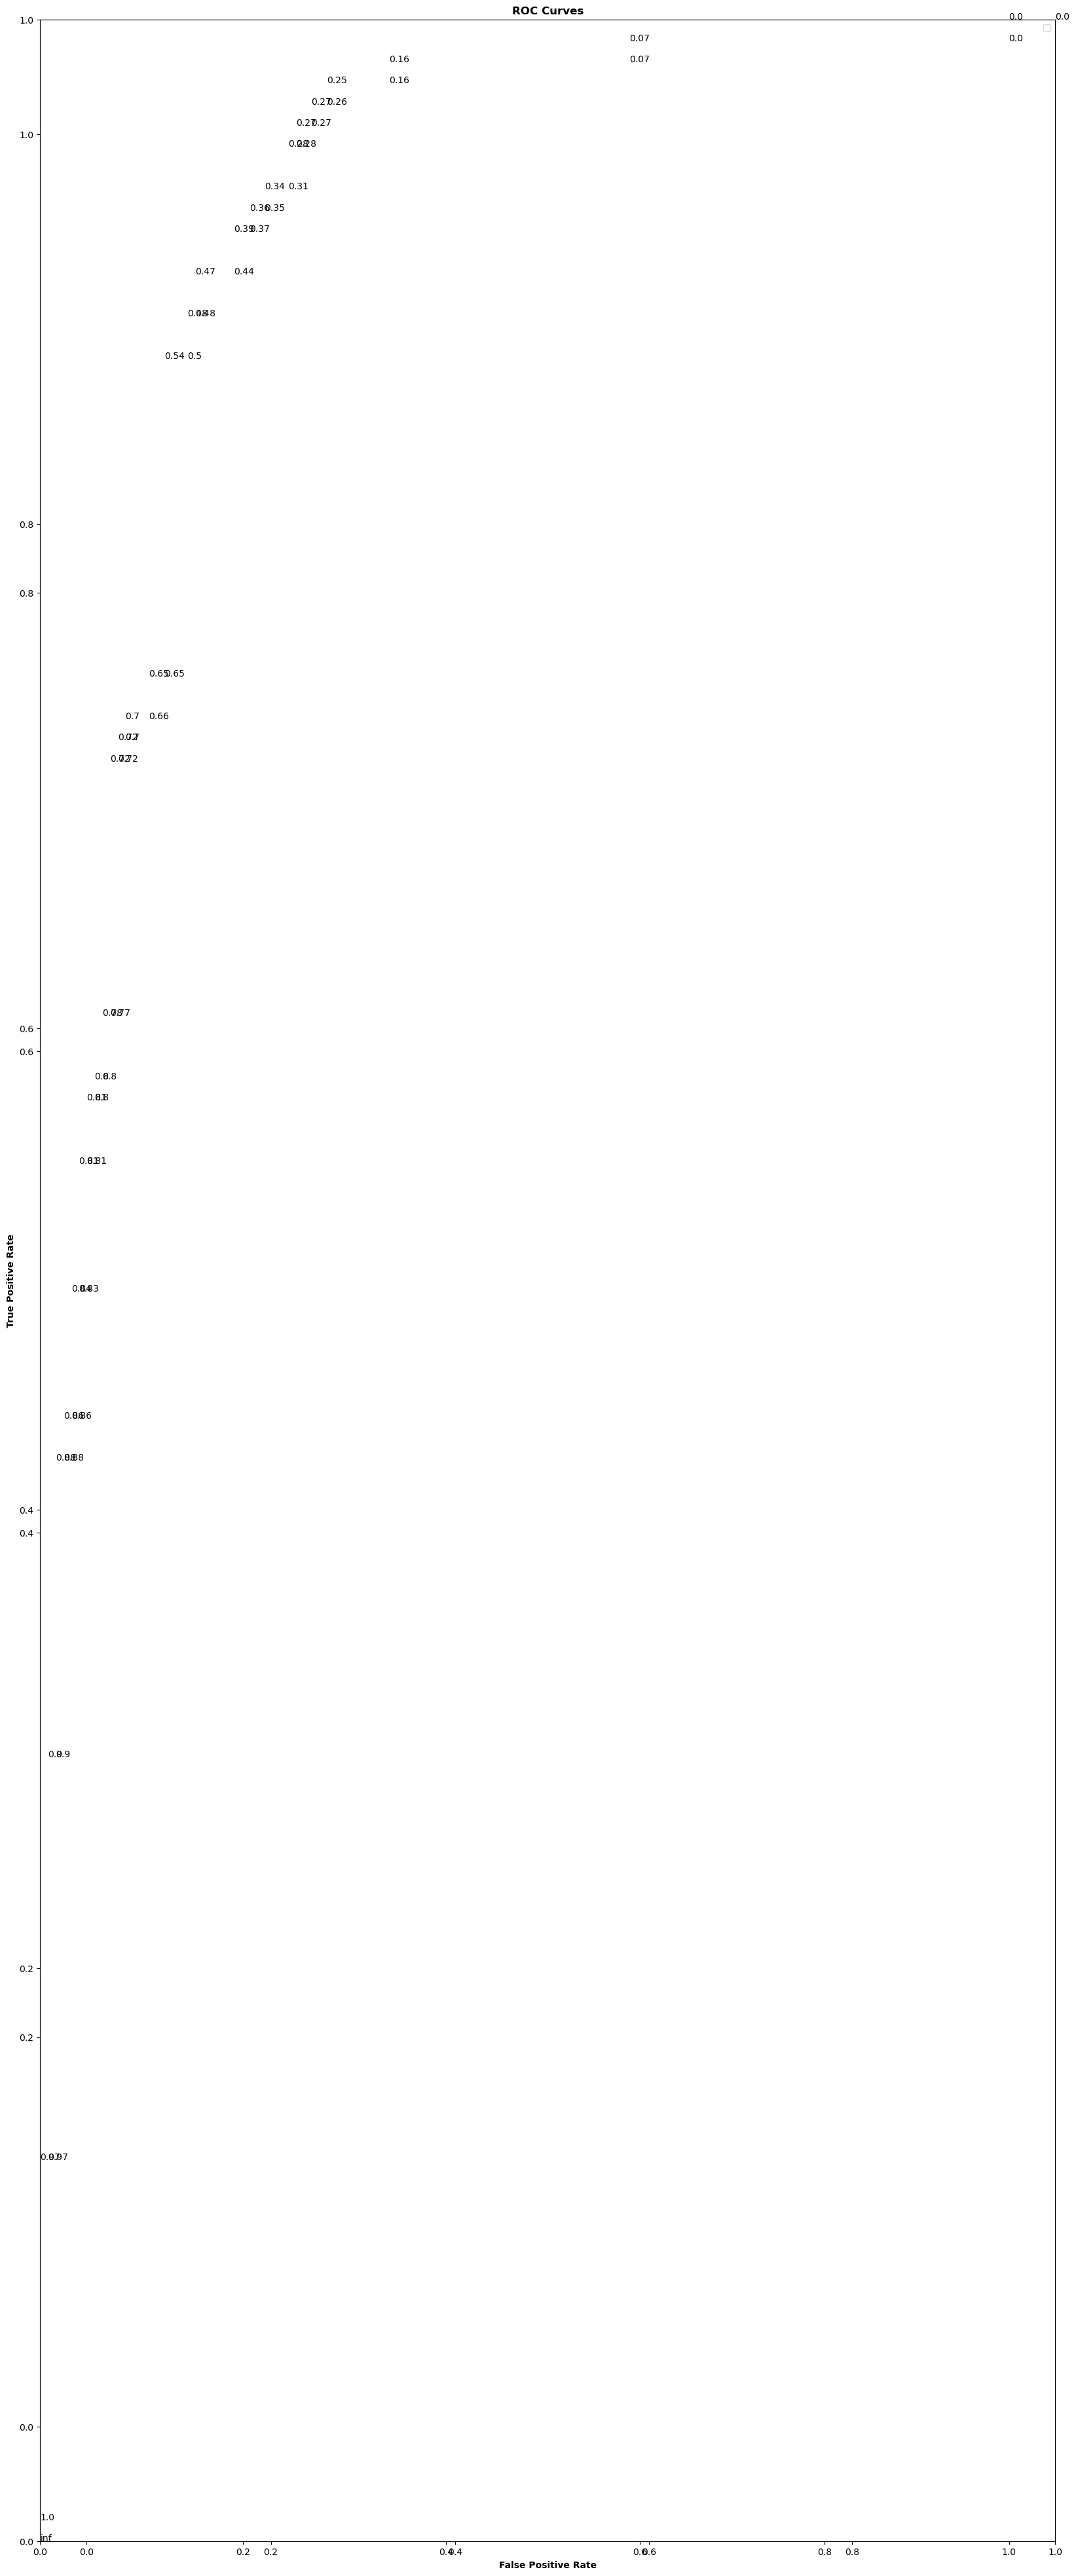

In [65]:
# plot the roc curve for the model
import numpy as np
fig=plt.figure(figsize=(20,50))
plt.plot(fpr_dummy, tpr_dummy, marker='.',linestyle='--', label='Dummy Model')
plt.plot(fpr_model, tpr_model, marker='.', label='Logistic Regression Model')
ax=fig.add_subplot(111)
for xyz in zip(fpr_model, tpr_model, thresholds):
    ax.annotate("%s" % np.round(xyz[2],2), xy=(xyz[0], xyz[1]))
plt.xlabel('False Positive Rate',weight='bold')
plt.ylabel('True Positive Rate',weight='bold')
plt.title('ROC Curves',weight='bold')
plt.legend()